In [1]:
# importing cfd_jacobian module
import numpy as np
from pyau3d.utils import PltFileUtils, GrpFileUtils, UnkFileUtils
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import pandas as pd
from cfd_jacobians import (
    compute_viscous_jacobian,
    compute_central_jacobian,
    compute_roe_jacobian,
)
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import eigs
# Enable interactive backend
%matplotlib widget

[inviscid_central] Building symbolic Jacobian...
[inviscid_roe] Building symbolic Jacobian...


In [2]:
# define required function

def specific_energy(rho, p, ux, uy, uz, gamma=1.4):
    return p / ((gamma - 1.0) * rho) + 0.5 * (ux**2 + uy**2 + uz**2)

def conservative_variables(rst, GAMMA):
    """Return conservative variables U on the surface."""
    E = specific_energy(rst.rho, rst.p, rst.ux, rst.uy, rst.uz, GAMMA)

    U = np.column_stack((
        rst.rho,
        rst.rho * rst.ux,
        rst.rho * rst.uy,
        rst.rho * rst.uz,
        rst.rho * E
    ))
    return U

In [3]:
# Load necessary files

dir = "/home/ahf25/CFD_2d_cylinder_all/Steady/2d_cylinder_12625_Re50"

pltfile = PltFileUtils(f"{dir}/cylinder.plt") # redefine file path later
rstfile = UnkFileUtils(f"{dir}/cylinder.rst", extend=False) # read file at iteraton = 101

# read fort file - [i nodes, j nodes, Ax, Ay, Az. cell volume]
fortfile = pd.read_csv(f"{dir}/fort.864",delim_whitespace=True, header=None)
fortfile = fortfile.to_numpy()

# Compute flow primitives 
rstfile._primitive()

# Extract list of coordinates (N,3)
coord = pltfile.coord


/tmp/ipykernel_40205/2084695243.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fortfile = pd.read_csv(f"{dir}/fort.864",delim_whitespace=True, header=None)


In [14]:
# define gamma - specific heat ratio
gamma = 1.4

# define laminar dynamic viscosity
mu = 1.8e-5
# define turbulent dynamic viscosity 
mu_t = 0 # zero in this laminar case

# define Reynolds number
Re = 50

# define laminar prandtl number
Pr = 0.72
# define turbulent prandtl number
Pr_t = 0.9


U = conservative_variables(rstfile, gamma) # compute conservative variables for n nodes (n, 5) array
i_nodes = fortfile[:,0].astype("i")
j_nodes = fortfile[:,1].astype("i")
A = fortfile[:,2:5]
V = fortfile[:,5]


In [15]:
# trial
indexi = 0
indexj = 0

# outer loop
node_i = i_nodes[0]

U_i = U[indexi,:] # U_i conservative variable vector for node i 
neighbours_j = j_nodes[i_nodes == node_i] # neighbours node j 
U_j_all = U[neighbours_j - 1 ,:] # U conservative variable vectors for all neighbouring nodes j (number_of_neighbours , 5)
V_i = V[indexi] # cell volume for node i
A_ij_all = A[i_nodes == node_i, :] # Aij area normal vector for all neighbouring nodes j (number_of_neighbours , 3)


# inner loop
U_j = U_j_all[indexj]
A_ij = A_ij_all[indexj,:]

# inviscid — central
dRi_dUi_c, dRi_dUj_c = compute_central_jacobian(U_i, U_j, A_ij, V_i, gamma)

# inviscid — Roe
dRi_dUi_r, dRi_dUj_r = compute_roe_jacobian(U_i, U_j, A_ij, V_i, gamma)



In [ ]:
# define number of nodes
N = np.shape(U)[0]

# initialise the jacobian matrix as a  List of Lists sparse matrix (lil_matrix) with size of (5*N, 5*N)
J_matrix = lil_matrix((5*N, 5*N))

# for indexi in range(N):
for indexi in range(1):
    node_i= indexi + 1 # define node i 

    U_i = U[indexi,:] # U_i conservative variable vector for node i 
    neighbours_j = j_nodes[i_nodes == node_i] # neighbours node j 
    U_j_all = U[neighbours_j - 1 ,:] # U conservative variable vectors for all neighbouring nodes j (number_of_neighbours , 5)
    V_i = V[indexi] # cell volume for node i
    A_ij_all = A[i_nodes == node_i, :] # Aij area normal vector for all neighbouring nodes j (number_of_neighbours , 3)
    print(f"for node {node_i}: ")
    print("U at node i: ", U_i)
    print("Aij(s): ",A_ij_all)
    print("corresponding Vi: ", V_i)

    for indexj in range(len(neighbours_j)):
        # indexj = 0
        node_j = neighbours_j[indexj] # extract the neighbouring node j 

        U_j = U_j_all[indexj]
        A_ij = A_ij_all[indexj,:]

        # viscous part 

        rho_i = U_i[0]
        rho_j = U_j[0]
        rho_ij = (rho_i + rho_j)/2 

        x_i = coord[node_i-1]
        x_j = coord[node_j-1]

        # viscous part compute, by default mu_t = 0, Pr_t = 0.9
        lam, J_visc = compute_viscous_jacobian(
        mu=mu, Pr=Pr, gamma=gamma, rho=rho_ij,
        xi=x_i, xj=x_j)


        # inviscid — central (the Aij is already absorbed inside)
        J_invisc_ii_Aij_c, J_invisc_ij_Aij_c = compute_central_jacobian(U_i, U_j, A_ij, V_i, gamma)

        # inviscid — Roe
        J_invisc_ii_Aij_r, J_invisc_ij_Aij_r = compute_roe_jacobian(U_i, U_j, A_ij, V_i, gamma)

        print("corresponding node j: ", node_j)
        print("corresponding Uj: ", U_j )
        print("corresponding Aij: ", A_ij )
        print(rho_i)
        print(rho_j)

        # note that Aij is not aborbed in the formulation of J_visc (viscous part)
        J_matrix[5*(node_i-1): 5*(node_i-1)+5, 5*(node_i-1): 5*(node_i-1)+5] += - J_invisc_ii_Aij_r + J_visc / Re * np.linalg.norm(A_ij)
        J_matrix[5*(node_i-1): 5*(node_i-1)+5, 5*(node_j-1): 5*(node_j-1)+5] = - J_invisc_ij_Aij_r

    print(J_matrix)
        

for node 1: 
U at node i:  [2.6762340e-05 7.7918323e-04 4.4787646e-04 9.4969764e-08 5.5504274e+00]
Aij(s):  [[ 4.088254e-04 -4.991780e-04 -8.712444e-04]
 [-8.518508e-04 -1.302292e-04 -9.534267e-04]
 [-5.556635e-04 -7.124772e-04 -2.529692e-04]
 [-1.032371e-03 -1.294444e-04  1.229490e-03]
 [ 3.612659e-04 -5.973888e-04  4.287262e-04]
 [ 9.375902e-04 -3.610654e-04 -3.141941e-04]
 [ 5.350568e-04 -9.291796e-05  1.105163e-03]
 [ 5.561666e-04  2.003515e-04 -1.646593e-05]
 [ 2.918256e-04  7.107273e-04 -1.067310e-03]
 [-6.569430e-04  7.414016e-04 -8.365934e-05]
 [ 6.097890e-06  8.702207e-04  7.958902e-04]]
corresponding Vi:  0.000325601
corresponding node j:  7829
corresponding Uj:  [ 2.6764184e-05  7.3485920e-04  4.8372918e-04 -2.4467688e-08
  5.5507541e+00]
corresponding Aij:  [ 0.00040883 -0.00049918 -0.00087124]
2.676234e-05
2.6764184e-05
corresponding node j:  9830
corresponding Uj:  [2.67748728e-05 7.60722323e-04 4.01512079e-04 1.03863975e-07
 5.55245876e+00]
corresponding Aij:  [-0.000851

In [17]:
# compute eigenvalues

# convert to CSR and test out eigensolver
J_matrix = J_matrix.tocsr()

# define Strohaul number obtained from unsteady CFD
St = 0.1469

# angular frequency (rad/s)
wr = St * 2 * np.pi

# growth rate
wi = 0.334

# define sigma - eigenvalues near sigma
sigma = 1j*wr + wi

# run eigs function
# Largest Real part LR
vals, vecs = eigs(J_matrix, k=20, sigma=sigma, which = "LM")

mode 1: imganiary = 0.0, real = -0.34745356744954364
mode 2: imganiary = 0.0, real = -0.4445548871797174
mode 3: imganiary = 0.7519089110510172, real = 2.6808676617012193
mode 4: imganiary = 0.0, real = 2.7074909170684003
mode 5: imganiary = -0.7519089110510172, real = 2.6808676617012193
mode 6: imganiary = 0.0, real = 4.57130016303244
mode 7: imganiary = 0.7152529499104556, real = 4.680242862781426
mode 8: imganiary = 0.0, real = 4.667699164762191
mode 9: imganiary = -0.7152529499104556, real = 4.680242862781426
mode 10: imganiary = 4.030936166569419, real = 4.057286106857093
mode 11: imganiary = 5.876935651038184, real = -1.0028960843049028
mode 12: imganiary = -4.030936166569419, real = 4.057286106857093
mode 13: imganiary = 0.0, real = 6.695594787078565
mode 14: imganiary = 6.746384537465002, real = 3.082312618183323
mode 15: imganiary = 0.0, real = 7.163524189521859
mode 16: imganiary = -5.876935651038184, real = -1.0028960843049028
mode 17: imganiary = -6.746384537465002, real = 

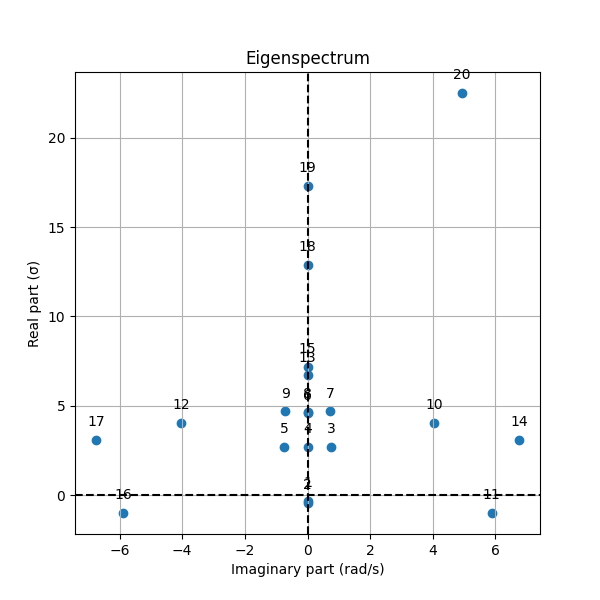

In [18]:
# plotting the eigen specturm

real = np.real(vals)
imag = np.imag(vals)

# filter out modes that are close to wr
close_to_wr = np.abs(wr - imag) < 0.1


plt.figure(figsize=(6,6))
plt.scatter(imag, real)

# plot close modes
plt.scatter(imag[close_to_wr], real[close_to_wr], color = "r")



# plot the number of modes on each data point as well

for i in range(len(real)):
    plt.annotate(i+1, (imag[i], real[i]), textcoords="offset points", xytext=(0,10), ha='center')
    print(f"mode {i+1}: imganiary = {imag[i]}, real = {real[i]}")


plt.axvline(0, color='k', linestyle='--')
plt.axhline(0, color='k', linestyle='--')

plt.ylabel("Real part (σ)")
plt.xlabel("Imaginary part (rad/s)")
plt.title("Eigenspectrum")
plt.grid(True)
plt.show()

In [19]:
# obtaining the modeshape
k = 15
nvar = 5
# Pick the k-th eigenvector (column)
vec = vecs[:, k-1]  

# Reshape to (N, 5) — each row is one node, each column is one variable
mode = vec.reshape(N, nvar)

# Extract individual variables across all nodes
rho_mode  = mode[:, 0]   # density perturbation    at all N nodes
u_mode  = mode[:, 1]   # u-velocity perturbation at all N nodes
v_mode  = mode[:, 2]   # v-velocity perturbation at all N nodes
w_mode  = mode[:, 3]   # w-velocity perturbationat all N nodes
E_mode = mode[:, 4]   # energy perturbation at all N nodes

# u_mode is complex — paper plots the real part
u_real = np.real(u_mode)          # shape (N,)

In [20]:
# Extract the side surface
side_coords, side_nodes, side_nodemap = pltfile.extract_surface(flag=3)

# note : flag = 3 is the flag on the out of plane surface, the xy plane
# flag = 4 is the bottom plane and flag = 3 is the top plane

# setting x and y bounds for the data
x_upper = 20
x_lower = -5
y_upper = 5
y_lower = -5

# use some utilities from GrpFileUtils
tmp_grp = GrpFileUtils('tmp', 0, 
                       read=False,
                       coord=side_coords, 
                       nodes=side_nodes)
tmp_grp.root_nodemap = side_nodemap 

# Filter points based on x and y coordinate bounds 
node_filter = (side_coords[:, 0] > x_lower) & (side_coords[:, 0] < x_upper) & (side_coords[:, 1] > y_lower) & (side_coords[:, 1] < y_upper )
tmp_grp.node_filter = node_filter

# Extract triangle nodemap
tri_nodemap = tmp_grp.get_tri_nodemap() 

# saving the x and y coordinates to grp_x and grp_y

grp_x = tmp_grp.coords[:, 0]
grp_y = tmp_grp.coords[:, 1]
# Construct a matplotlib Triangulation (defines our mesh for plotting)
tri = Triangulation(grp_x, grp_y, triangles=tri_nodemap)



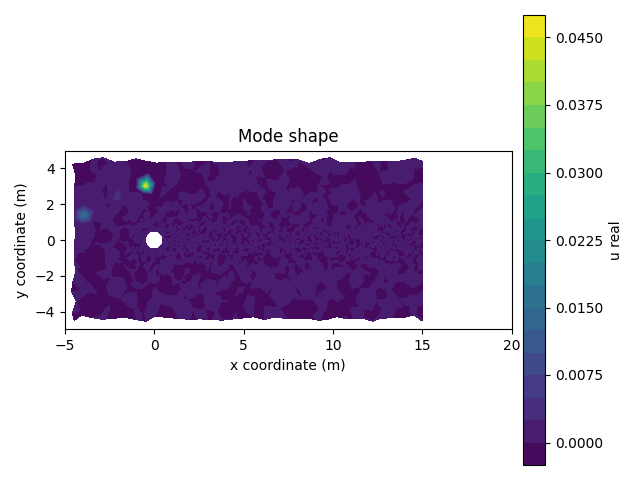

In [21]:
# density plot
fig, ax = plt.subplots()

# Note, we need to apply the node_filter to the pressure array 
# because it still contains values for every node on the casing
contour = ax.tricontourf(tri, u_real[side_nodes][node_filter], levels=20)
fig.colorbar(contour, ax=ax, pad=0.02, label='u real')
ax.set_title("Mode shape")
ax.set_xlabel("x coordinate (m)")
ax.set_ylabel("y coordinate (m)")
ax.set_aspect('equal', 'box') # forcing the scale of x and y axis to equal
ax.set_xlim(x_lower, x_upper)
ax.set_ylim(y_lower, y_upper)
plt.tight_layout()
plt.show()

In [22]:
# testing
# --- shared test data ---
gamma = 1.4
rho_i, rho_j = 1.0, 1.1
Ui  = np.array([rho_i, rho_i*0.5, rho_i*0.2, 0.0, rho_i*2.5])
Uj  = np.array([rho_j, rho_j*0.4, rho_j*0.1, 0.0, rho_j*2.3])
Aij = np.array([1.0, 0.0, 0.0])
Vi  = 0.1

# viscous
lam, J_visc = compute_viscous_jacobian(
    mu=1.8e-5, Pr=0.72, gamma=gamma, rho=1.05,
    xi=[0.0, 0.0, 0.0], xj=[0.1, 0.0, 0.0]
)

# inviscid — central
dRi_dUi_c, dRi_dUj_c = compute_central_jacobian(Ui, Uj, Aij, Vi, gamma)

# inviscid — Roe
dRi_dUi_r, dRi_dUj_r = compute_roe_jacobian(Ui, Uj, Aij, Vi, gamma)